# 1. Flow network

## 1.1 Defining a demo flow network in `networx` library based on Wikipedia example

In [ ]:
import networkx as nx
from flow_network_visualization import plot_flow_graph

# Using a simple example flow network based on wikipedia's max flow example, we'll define a directed graph using networkx library.

def demo_network() -> tuple[nx.DiGraph, dict]:
    G = nx.DiGraph()

    arcs = [
        ("s", "a", 8),
        ("s", "b", 4),
        ("a", "b", 6),
        ("a", "c", 4),
        ("b", "d", 6),
        ("c", "d", 2),
        ("c", "t", 4),
        ("d", "t", 8),
    ]

    for u, v, capacity in arcs:
        G.add_edge(u, v, capacity=capacity)
    
    pos = {"s": (0, 0), "a": (1, 0.8), "b": (1, -0.8),
           "c": (2, 0.8), "d": (2, -0.8), "t": (3, 0)}
    return G, pos
    



## 1.2 Solving Max Flow using Edmonds-Karp Algorithm (networkx library)

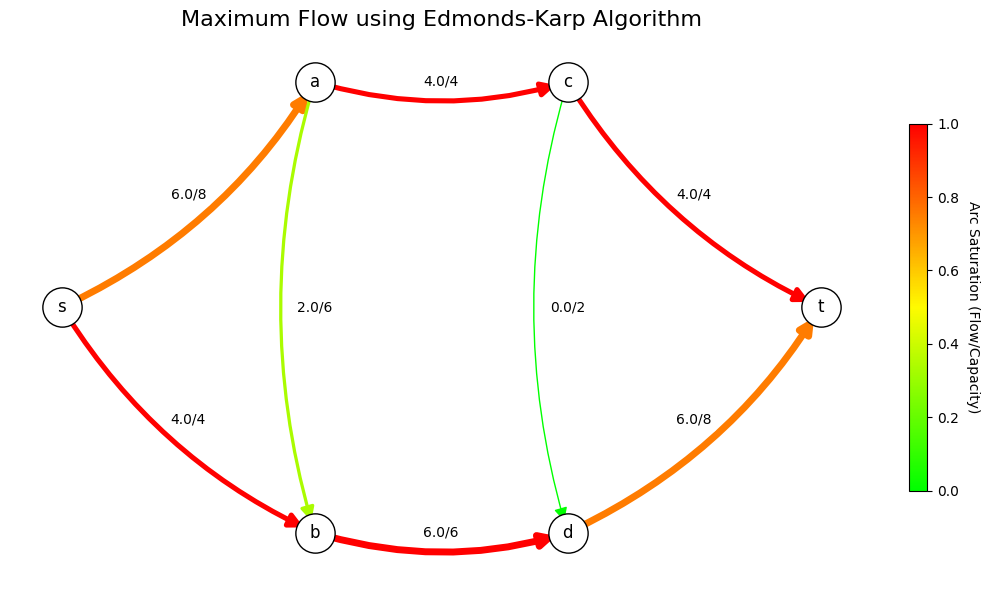

In [4]:
G, pos = demo_network()
# Residual graph R
R = nx.algorithms.flow.edmonds_karp(G, "s", "t")
node_flows = nx.algorithms.flow.build_flow_dict(G, R)
flow_dict = {(u, v): node_flows[u][v] for u in node_flows for v in node_flows[u]}
#plot_network(G, flow_dict, pos, title="Maximum Flow using Edmonds-Karp Algorithm")
plot_flow_graph(G, flow_dict, pos, title="Maximum Flow using Edmonds-Karp Algorithm", show_saturation=True)



## 1.2 Solving Max Flow using cvxpy library (Linear Programing formulation)

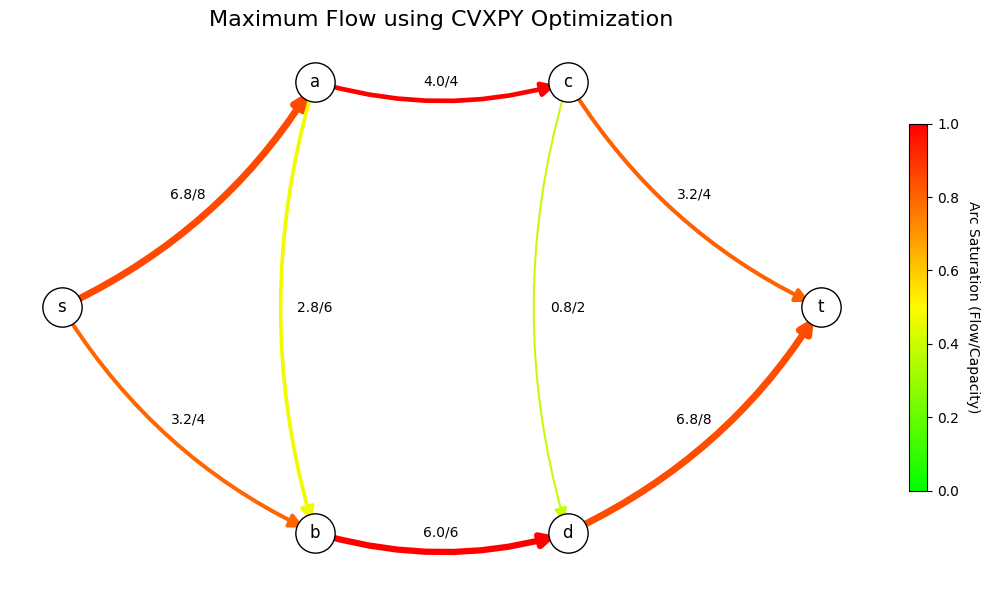

In [19]:

import cvxpy
import numpy as np

G, pos = demo_network()

# incidence_mx @ capacity_vector gives an equivalent definition to nx.add_edge(u, v, capacity=capacity) for all edges in G, but in a vectorized form.
incidence_mx = np.asarray(nx.incidence_matrix(G, oriented=True).todense())
capacity_vector = np.array([d['capacity'] for (_, _, d) in G.edges(data=True)])
flow_vector = cvxpy.Variable(len(G.edges()), nonneg=True)

# Remove the row corresponding to the source 's' and sink 't' to get the flow conservation constraints 
A = incidence_mx[1:-1, :]
constraints = [
    flow_vector <= capacity_vector, # Capacity constraints
    A @ flow_vector == 0, # Flow conservation constraints
    ]

q = np.array([1 if u == "s" else -1 if v == "s" else 0 for u, v in G.edges()])
# Objective function to maximize flow out of source 's'
objective = cvxpy.Maximize(q @ flow_vector)
problem = cvxpy.Problem(objective, constraints)
problem.solve()

flow_dict = { (u, v): flow_vector[i].value for i, (u, v) in enumerate(G.edges()) }
plot_flow_graph(G, flow_dict, pos, title="Maximum Flow using CVXPY Optimization", show_saturation=True)



## 1.3 Max-flow min-cut theorem

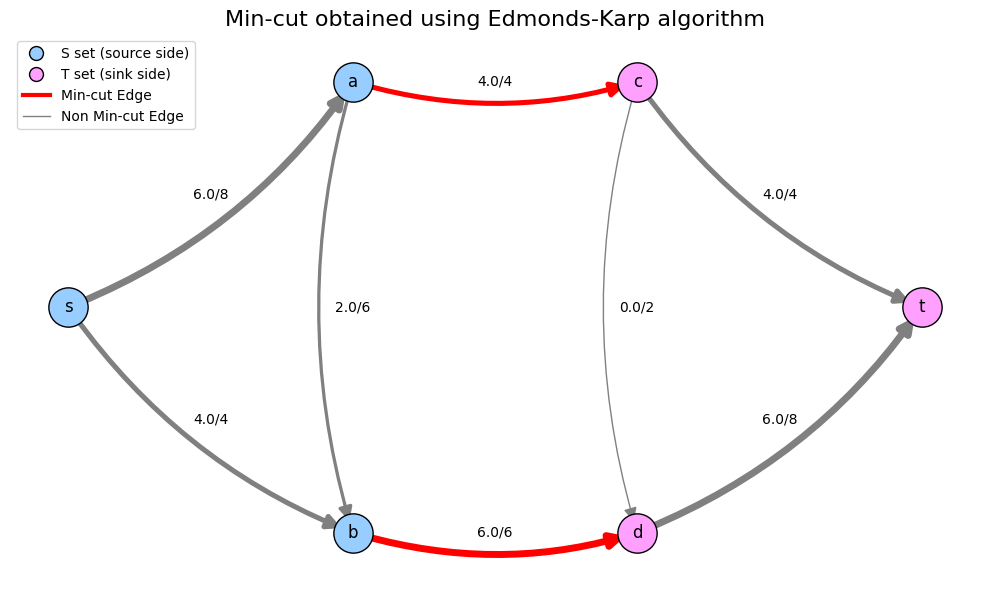

In [14]:
from collections import deque

G, pos = demo_network()
# Residual graph R
R = nx.algorithms.flow.edmonds_karp(G, "s", "t")
flow_value = R.graph["flow_value"]   # stored in graph metadata

capacity_dict = {(u, v): d['capacity'] for u, v, d in G.edges(data=True)}
flow_dict = nx.algorithms.flow.build_flow_dict(G, R)
flow_dict = {(u, v): flow_dict[u][v] for u in flow_dict for v in flow_dict[u]}
# BFS in residual — all edges in R have residual capacity
S = set()
q = deque(["s"])
S.add("s")
while q:
    u = q.popleft()
    for v in R.successors(u):
        residual_capacity = capacity_dict.get((u, v), 0) - flow_dict.get((u, v), 0)
        if v not in S and residual_capacity > 0:
            S.add(v)
            q.append(v)

# Min-cut: edges from S to not-S in original graph
min_cut = [(u, v) for u, v in G.edges() if u in S and v not in S]
T = set(G.nodes()) - S


    
plot_flow_graph(G, flow_dict, pos, title="Min-cut obtained using Edmonds-Karp algorithm", show_saturation=False, S=S, T=T, cut_edges=min_cut)




## 1.4 Max-flow min-cut using cvxpy - dual linear program

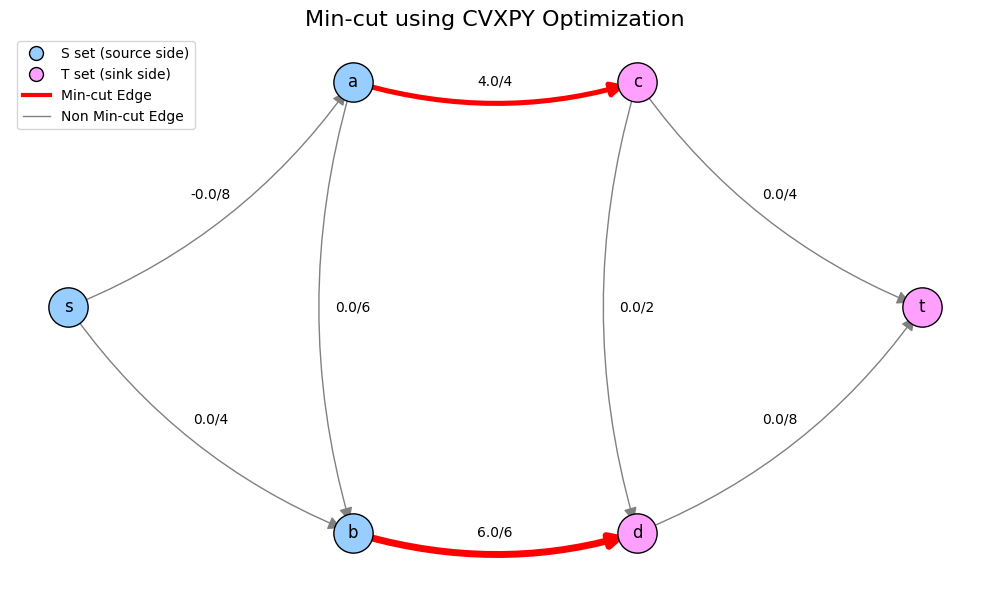

array([-1., -1.,  0.,  0.])

In [ ]:

import cvxpy
from cvxpy.settings import DEFAULT_CANON_BACKEND
import numpy as np

G, pos = demo_network()

# incidence_mx @ capacity_vector gives an equivalent definition to nx.add_edge(u, v, capacity=capacity) for all edges in G, but in a vectorized form.
incidence_mx = np.asarray(nx.incidence_matrix(G, oriented=True).todense())
# Remove the row corresponding to the source 's' and sink 't' to get the flow conservation constraints 
A = incidence_mx[1:-1, :]
capacity_vector = np.array([d['capacity'] for (_, _, d) in G.edges(data=True)])
q = np.array([1 if u == "s" else -1 if v == "s" else 0 for u, v in G.edges()])

# potentials for nodes excluding source and sink
node_potential = cvxpy.Variable(len(G.nodes()) - 2) 
 # indicate if an edge is in the cut
edge_inclusion = cvxpy.Variable(len(G.edges()), boolean=True)
# Objective function to minimize the capacity of edges in the cut
objective = cvxpy.Minimize(capacity_vector @ edge_inclusion)

# Constraints of the max-flow min-cut dual problem
constraints = []

constraints.append(edge_inclusion - node_potential @ A >= q)ve
    
problem = cvxpy.Problem(objective, constraints)
problem.solve()

edge_dict = { (u, v): edge_inclusion[i].value for i, (u, v) in enumerate(G.edges()) }
cvxpy_min_cut = [(u, v) for (u, v), value in edge_dict.items() if value is not None and value > 0.5]
flow_dict = { (u, v): edge_inclusion[i].value * capacity_vector[i] for i, (u, v) in enumerate(G.edges()) }
graph_without_cut = G.copy()
graph_without_cut.remove_edges_from(cvxpy_min_cut)
S = nx.descendants(graph_without_cut, "s") | {"s"}
T = set(G.nodes()) - S
plot_flow_graph(G, flow_dict, pos, title="Min-cut using CVXPY Optimization", show_saturation=False, 
                S=S, T=T, cut_edges=cvxpy_min_cut)
node_potential.value


## 1.5 Feasible region